# Tiny Companion: Chi-Squared Test for Categorical Drift

Use this notebook when the feature is a **category**, not a numeric value.

Examples:
- `city`
- `device type`
- `plan type`

If the feature is numeric, such as mileage or apartment size, use **KS** or **PSI** instead.

,train,prod
Ahmedabad,400,200
Rajkot,350,200
Surat,250,600


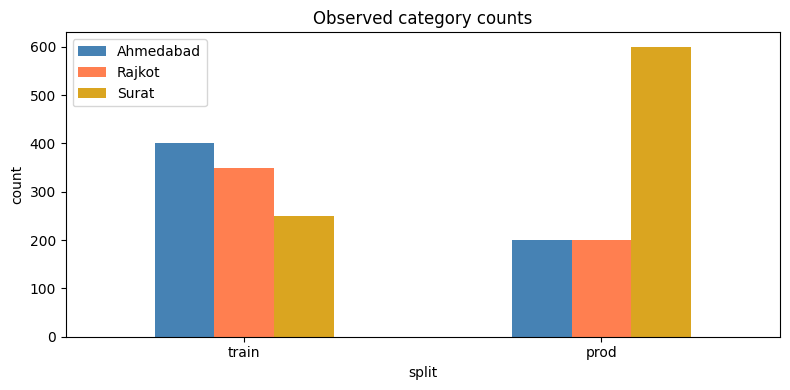

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from IPython.display import display

plt.style.use('default')

table = pd.DataFrame(
    {
        'train': [400, 350, 250],
        'prod': [200, 200, 600],
    },
    index=['Ahmedabad', 'Rajkot', 'Surat'],
)

display(table)
ax = table.T.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'coral', 'goldenrod'])
ax.set_title('Observed category counts')
ax.set_ylabel('count')
ax.set_xlabel('split')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 1: What would **no real change** look like?

If there were no meaningful drift, training and production should distribute the city counts more similarly.

So we compute the **expected** counts under that no-change story.

In [2]:
row_totals = table.sum(axis=1)
col_totals = table.sum(axis=0)
grand_total = table.values.sum()

expected = pd.DataFrame(index=table.index, columns=table.columns, dtype=float)
for row in table.index:
    for col in table.columns:
        expected.loc[row, col] = row_totals[row] * col_totals[col] / grand_total

print('Column totals:')
display(col_totals.to_frame(name='total'))
print('Row totals:')
display(row_totals.to_frame(name='total'))
print(f'Grand total: {grand_total}')
print()
print('Expected counts if there were no real change:')
display(expected)

Column totals:


,total
train,1000
prod,1000


Row totals:


,total
Ahmedabad,600
Rajkot,550
Surat,850


Grand total: 2000

Expected counts if there were no real change:


,train,prod
Ahmedabad,300.0,300.0
Rajkot,275.0,275.0
Surat,425.0,425.0


## Step 2: Turn each mismatch into a contribution

For each cell:

```text
contribution = (observed - expected)^2 / expected
```

Bigger mismatches give bigger contributions. Then we add them all.

In [3]:
contrib = (table - expected) ** 2 / expected
print('Per-cell contributions:')
display(contrib)
print(f'chi^2 by adding all contributions = {contrib.to_numpy().sum():.2f}')

Per-cell contributions:


,train,prod
Ahmedabad,33.333333,33.333333
Rajkot,20.454545,20.454545
Surat,72.058824,72.058824


chi^2 by adding all contributions = 251.69


## Step 3: Let SciPy compute the final test result

Now we run the actual chi-squared test. It returns:
- `chi2`: the total mismatch score
- `p`: how surprising that score would be if there were really no meaningful change

In [4]:
chi2, p, dof, expected_scipy = chi2_contingency(table)
print(f'chi2 = {chi2:.2f}')
print(f'p = {p:.2e}')
print(f'degrees of freedom = {dof}')

chi2 = 251.69
p = 2.22e-55
degrees of freedom = 2


## Gentle reading

- if counts are close, `p-value` stays larger
- if counts are very different, `p-value` becomes smaller
- here `p` is extremely small, so the city mix changed far too much to explain as random wobble alone

Quick rule:
- numeric feature -> **KS** or **PSI**
- categorical feature -> **chi-squared**
- labels are also categories, so the same test can also compare old vs new label counts